# 01 — Empirical Observation of Benford's Law

This notebook reproduces Benford's 1938 tabulation on three datasets:

1. **World city populations** — real, Benford-conforming.
2. **Fibonacci sequence** — synthetic, Benford-conforming.
3. **Adult human heights** — synthetic, *expected to fail*.

It produces `figures/empirical_match.png`, the figure embedded in §2 of the TIL.

**Prerequisite.** Run `python scripts/build_datasets.py` once to populate `data/raw/world_cities.csv`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.benford import benford_pmf, empirical_frequencies
from src.datasets import adult_heights, fibonacci_sample, load_world_cities

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = REPO_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

DIGITS = np.arange(1, 10)
PMF = benford_pmf()

## 1. World city populations

In [2]:
try:
    cities = load_world_cities(min_population=1)
    cities_freq = empirical_frequencies(cities["population"].to_numpy())
    n_cities = len(cities)
    print(f"n = {n_cities:,} cities")
    print("d  empirical  benford  diff")
    for d, e, b in zip(DIGITS, cities_freq, PMF):
        print(f"{d}  {e:.4f}     {b:.4f}   {e - b:+.4f}")
except FileNotFoundError as exc:
    cities_freq = None
    n_cities = 0
    print(f"SKIPPED: {exc}")
    print("Run `python scripts/build_datasets.py` from the repo root and re-run this cell.")

SKIPPED: C:\Users\bruno\Desktop\Projetos\benford-law-til\data\raw\world_cities.csv not found. Run `python scripts/build_datasets.py` first.
Run `python scripts/build_datasets.py` from the repo root and re-run this cell.


## 2. Fibonacci numbers (synthetic, conforming)

In [3]:
fib = fibonacci_sample(1000)
fib_freq = empirical_frequencies(fib)
print("d  empirical  benford  diff")
for d, e, b in zip(DIGITS, fib_freq, PMF):
    print(f"{d}  {e:.4f}     {b:.4f}   {e - b:+.4f}")

d  empirical  benford  diff
1  0.3010     0.3010   -0.0000
2  0.1770     0.1761   +0.0009
3  0.1250     0.1249   +0.0001
4  0.0960     0.0969   -0.0009
5  0.0800     0.0792   +0.0008
6  0.0670     0.0669   +0.0001
7  0.0560     0.0580   -0.0020
8  0.0530     0.0512   +0.0018
9  0.0450     0.0458   -0.0008


## 3. Adult heights (synthetic, expected to fail)

In [4]:
heights = adult_heights(n=20_000, mean_cm=170.0, sd_cm=10.0, seed=0)
heights_freq = empirical_frequencies(heights)
print("d  empirical  benford  diff")
for d, e, b in zip(DIGITS, heights_freq, PMF):
    print(f"{d}  {e:.4f}     {b:.4f}   {e - b:+.4f}")

d  empirical  benford  diff
1  0.9988     0.3010   +0.6978
2  0.0012     0.1761   -0.1749
3  0.0000     0.1249   -0.1249
4  0.0000     0.0969   -0.0969
5  0.0000     0.0792   -0.0792
6  0.0000     0.0669   -0.0669
7  0.0000     0.0580   -0.0580
8  0.0000     0.0512   -0.0512
9  0.0000     0.0458   -0.0458


## Figure: empirical vs theoretical

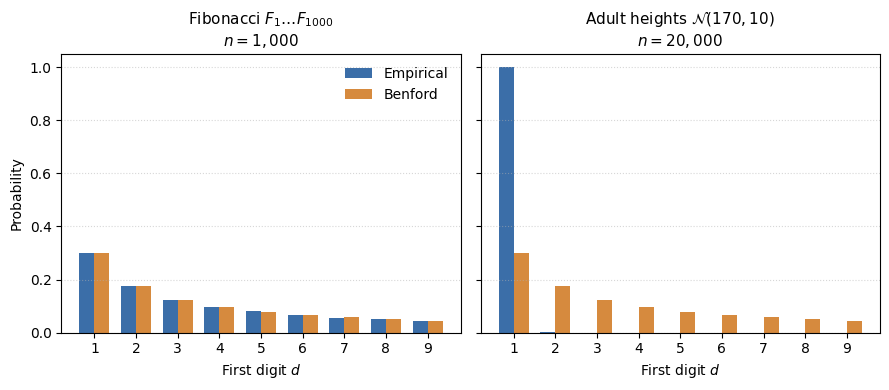

In [5]:
datasets = []
if cities_freq is not None:
    datasets.append(("World city populations", cities_freq, n_cities))
datasets.append(("Fibonacci $F_1\\ldots F_{1000}$", fib_freq, len(fib)))
datasets.append(("Adult heights $\\mathcal{N}(170, 10)$", heights_freq, len(heights)))

ncols = len(datasets)
fig, axes = plt.subplots(1, ncols, figsize=(13 if ncols == 3 else 9, 4), sharey=True)
if ncols == 1:
    axes = [axes]

for ax, (title, freq, n) in zip(axes, datasets):
    bar_x = DIGITS - 0.18
    line_x = DIGITS + 0.18
    ax.bar(bar_x, freq, width=0.36, label="Empirical", color="#3b6ea8")
    ax.bar(line_x, PMF, width=0.36, label="Benford", color="#d68a3e")
    ax.set_xticks(DIGITS)
    ax.set_xlabel("First digit $d$")
    ax.set_title(f"{title}\n$n = {n:,}$", fontsize=11)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
axes[0].set_ylabel("Probability")
axes[0].legend(loc="upper right", frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "empirical_match.png", dpi=300, bbox_inches="tight")
plt.show()

## Reading the figure

The first two panels track $\log_{10}(1 + 1/d)$ closely; the third does not. The contrast motivates the structural question Phase 2 will answer: *what property of a dataset forces (or breaks) the logarithmic distribution?*